# Noise Annealed Flux Matching — Quickstart

This notebook extends the [Flux Matching quickstart](flux_matching_quickstart.ipynb) with **noise annealed Flux Matching** where we learn generative vector fields for a continuum of noised distributions (like diffusion models). Instead of using a fixed $\sigma$, we sample $\sigma$ from a noise distribution.

We need $2$ additional components to do noise annealed Flux Matching:
1. A **Sigma sampler** — draws a noise level each batch. We use the variance exploding formulation here.
2. An **`LossNormalizer`** $s_{\eta}$ — learns to reweight losses across different sigmas

In [348]:
from src.loss import flux_matching_loss
from src.normalizer import LossNormalizer
import sys
sys.path.insert(0, '..')

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 1. Data

We use a 2D ring as the target distribution.

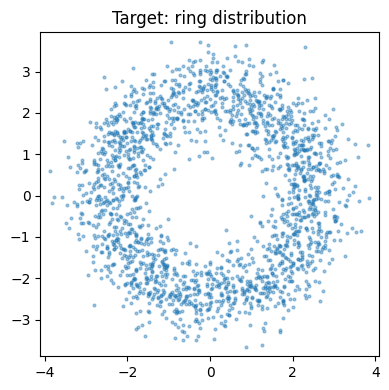

In [349]:
RING_RADIUS = 2.5
RING_WIDTH  = 0.5

def sample_ring(n: int) -> torch.Tensor:
    theta = 2 * torch.pi * torch.rand(n, device=DEVICE)
    r     = RING_RADIUS + RING_WIDTH * torch.randn(n, device=DEVICE)
    return torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=-1)

data = sample_ring(2000).cpu()
plt.figure(figsize=(4, 4))
plt.scatter(data[:, 0], data[:, 1], s=4, alpha=0.4)
plt.title('Target: ring distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 2. Noise Level $\sigma$ Sampler

Instead of a fixed `sigma2`, we sample a noise level $\sigma$ each iteration from a log-uniform distribution:
$$\log \sigma \sim \text{Uniform}[\log \sigma_{\min},\, \log \sigma_{\max}]$$

This is the **variance-exploding (VE)** schedule.

In [350]:
SIGMA_MIN = 0.02
SIGMA_MAX = 2.0

def sample_sigma() -> torch.Tensor:
    log_sigma = torch.empty(1, device=DEVICE).uniform_(torch.log(torch.tensor(SIGMA_MIN)),
                                                       torch.log(torch.tensor(SIGMA_MAX)))
    return log_sigma.exp().squeeze()

## 3. Initializing $f_{\theta}^{\sigma}$, $s_{\eta}$
- $f_{\theta}^{\sigma}$ is a noise conditioned vector valued model, so we need one additional dimension for the input to pass in the noise level $\sigma$
- $s_{\eta}$ is a small 1-layer MLP that parameterizes a learnable reweighting of the loss across different noise levels $\sigma$

In [351]:
f_theta = nn.Sequential(
    nn.Linear(2 + 1, 256), nn.SiLU(),
    nn.Linear(256, 256), nn.SiLU(),
    nn.Linear(256, 2),
).to(DEVICE)

s = LossNormalizer().to(DEVICE)

## 4. Train

Each iteration:
1. Sample a batch of data and a noise level `sigma`
2. Compute `flux_matching_loss`
3. Update `f_theta` on the Flux Matching loss
4. Update loss normalizer `s`

In [352]:
opt_f = torch.optim.Adam(f_theta.parameters(), lr=1e-3)
opt_s = torch.optim.Adam(s.parameters(),       lr=1e-3)

for step in range(50000):
    x      = sample_ring(512)
    sigma  = sample_sigma()
    sigma2 = sigma.pow(2)

    loss_normalization = s(sigma)

    def f_theta_noise_conditioned(x):
        return f_theta(torch.cat([x, sigma.expand(x.shape[0], 1)], dim=-1))

    loss = flux_matching_loss(f_theta_noise_conditioned, x, sigma2) / torch.exp(loss_normalization) + loss_normalization

    opt_f.zero_grad(); opt_s.zero_grad()
    loss.mean().backward()
    opt_f.step(); opt_s.step()

    if (step + 1) % 500 == 0:
        print(f'step {step+1:4d}  loss={loss.mean().item():.4f}')

print('Training Complete.')

step  500  loss=128.6256
step 1000  loss=4.9116
step 1500  loss=5.2498
step 2000  loss=6.1430
step 2500  loss=6.6353
step 3000  loss=399.9927
step 3500  loss=6.9910
step 4000  loss=5.8618
step 4500  loss=24.8936
step 5000  loss=6.9441
step 5500  loss=11.6076
step 6000  loss=9.0372
step 6500  loss=9.6555
step 7000  loss=9.9136
step 7500  loss=10.6483
step 8000  loss=8.1468
step 8500  loss=9.7721
step 9000  loss=91.6942
step 9500  loss=10.3911
step 10000  loss=6.7205
step 10500  loss=9.5525
step 11000  loss=12.9124
step 11500  loss=12.9700
step 12000  loss=7.7150
step 12500  loss=6.3902
step 13000  loss=14.1732
step 13500  loss=14.5458
step 14000  loss=7.6699
step 14500  loss=7.1677
step 15000  loss=15.1778
step 15500  loss=11.2677
step 16000  loss=7.0284
step 16500  loss=14.4732
step 17000  loss=11.3199
step 17500  loss=21.9891
step 18000  loss=4.1297
step 18500  loss=15.6912
step 19000  loss=16.3972
step 19500  loss=11.0090
step 20000  loss=7.4958
step 20500  loss=-2.5165
step 21000  l

## 5. Sample with the reverse-time SDE (Euler-Maruyama)

With a VE schedule $\sigma(t)$ decreasing from $\sigma_\text{max}$ to $\sigma_\text{min}$, the reverse-time SDE is:

$$dx = -\dot\sigma\,\sigma\, f_\theta(x)\, dt + \sqrt{2\dot\sigma\sigma}\, dW$$

We discretise this with Euler-Maruyama over $N$ steps, linearly spacing $\sigma$ in log-space from $\sigma_\text{max}$ down to $\sigma_\text{min}$.

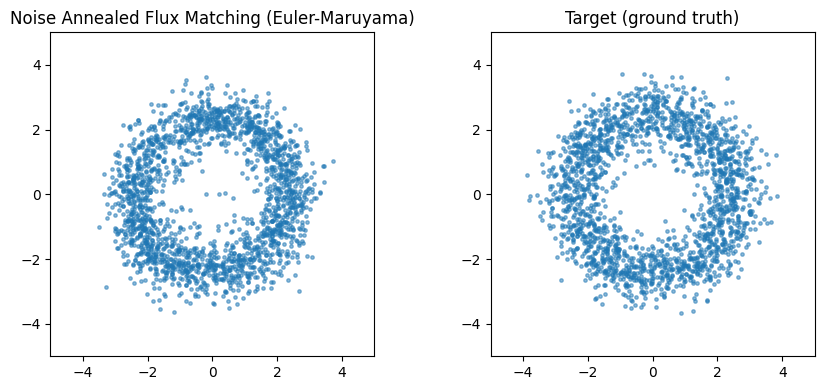

In [353]:
@torch.no_grad()
def euler_maruyama_sample(net, n=2000, steps=1000):
    sigmas = torch.logspace(
        torch.log10(torch.tensor(SIGMA_MAX, device=DEVICE)),
        torch.log10(torch.tensor(SIGMA_MIN, device=DEVICE)),
        steps + 1,
        device=DEVICE,
    )

    x = sigmas[0] * torch.randn(n, 2, device=DEVICE)

    for i in range(steps):
        sigma_cur = sigmas[i]
        sigma_next = sigmas[i + 1]

        dvar = sigma_cur.square() - sigma_next.square()
        field = net(torch.cat([x, sigma_cur.expand(x.shape[0], 1)], dim=-1))

        drift = dvar * field
        diffusion = dvar.sqrt() * torch.randn_like(x)

        x = x + drift + diffusion

    return x.cpu()


samples = euler_maruyama_sample(f_theta)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pts, title in zip(axes,
    [samples, data],
    ['Noise Annealed Flux Matching (Euler-Maruyama)', 'Target (ground truth)']):
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.set_title(title)
plt.tight_layout()
plt.show()

## 6. Variance Reduction with an Importance Sampler

In more complex settings than this toy dataset, we may want to reduce variance of the horizon sampler for the diffusion simulation. This is especially relevant here since we train across a wide range of noise levels ($\sigma \in [0.02, 2]$). Here, we quickly show how to learn a cheap importance sampler that can be trained simultaneously with the main network.

We load `ExponentialIS` from `src/exponential.py` and train it jointly with `f_theta` and `s`. The loss already accepts an optional `q` argument, so passing the sampler is all that is needed.

In [354]:
from src.exponential import ExponentialIS

f_theta_is = nn.Sequential(
    nn.Linear(2 + 1, 256), nn.SiLU(),
    nn.Linear(256, 256), nn.SiLU(),
    nn.Linear(256, 2),
).to(DEVICE)

s_is   = LossNormalizer().to(DEVICE)
q_phi  = ExponentialIS().to(DEVICE)

opt_f = torch.optim.Adam(f_theta_is.parameters(), lr=1e-3)
opt_s = torch.optim.Adam(s_is.parameters(),       lr=1e-3)
opt_q = torch.optim.Adam(q_phi.parameters(),      lr=1e-3)

for step in range(50000):
    x      = sample_ring(512)
    sigma  = sample_sigma()
    sigma2 = sigma.pow(2)

    loss_normalization = s_is(sigma)

    def f_theta_noise_conditioned(x):
        return f_theta_is(torch.cat([x, sigma.expand(x.shape[0], 1)], dim=-1))

    per_sample, t = flux_matching_loss(
        f_theta_noise_conditioned, x, sigma2, q=q_phi, return_t=True
    )

    loss = per_sample / torch.exp(loss_normalization) + loss_normalization

    reinforce = q_phi.reinforce_loss(t.expand(x.shape[0]), sigma, (per_sample / torch.exp(loss_normalization)).mean().detach())

    opt_f.zero_grad(); opt_s.zero_grad(); opt_q.zero_grad()
    (loss.mean() + reinforce.mean()).backward()
    opt_f.step(); opt_s.step(); opt_q.step()

    if (step + 1) % 500 == 0:
        print(f'step {step+1:4d}  loss={loss.mean().item():.4f}')

print('Training with IS complete.')

step  500  loss=3.2694
step 1000  loss=15.0124
step 1500  loss=9.0980
step 2000  loss=4.3445
step 2500  loss=4.2029
step 3000  loss=5.5860
step 3500  loss=4.6924
step 4000  loss=5.8715
step 4500  loss=17.6600
step 5000  loss=5.9455
step 5500  loss=101.1234
step 6000  loss=8.5118
step 6500  loss=7.9523
step 7000  loss=6.5909
step 7500  loss=7.5375
step 8000  loss=8.3850
step 8500  loss=10.0571
step 9000  loss=7.1287
step 9500  loss=8.3940
step 10000  loss=6.9158
step 10500  loss=11.0408
step 11000  loss=7.1584
step 11500  loss=13.5643
step 12000  loss=8.8712
step 12500  loss=8.1405
step 13000  loss=8.4964
step 13500  loss=7.3819
step 14000  loss=9.2771
step 14500  loss=11.4757
step 15000  loss=11.3272
step 15500  loss=13.0565
step 16000  loss=7.7482
step 16500  loss=9.7356
step 17000  loss=6.5708
step 17500  loss=12.0362
step 18000  loss=17.3633
step 18500  loss=4.6250
step 19000  loss=-2.1632
step 19500  loss=0.5283
step 20000  loss=15.6321
step 20500  loss=-2.6686
step 21000  loss=14.

We can also do the Euler-Maruyama sampling again with the new model.

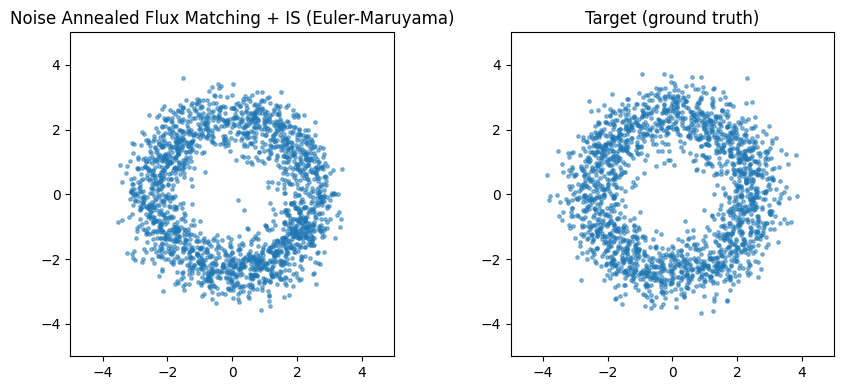

In [355]:
samples_is = euler_maruyama_sample(f_theta_is)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pts, title in zip(axes,
    [samples_is, data],
    ['Noise Annealed Flux Matching + IS (Euler-Maruyama)', 'Target (ground truth)']):
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal'); ax.set_title(title)
plt.tight_layout()
plt.show()